# Quantitative Evaluation

We evaluate the Bayesian Network as a binary classifier and compare it against four sklearn baselines using **5-fold stratified cross-validation**.

**Metrics:** Accuracy, Precision, Recall, F1, AUC-ROC, Log-Likelihood, Brier Score, Predictive Entropy, ECE  
**Baselines:** Logistic Regression, Naive Bayes (Categorical), Random Forest, SVM

**Classification procedure:** For each test sample, all non-target features are provided as evidence to Variable Elimination, yielding P(num=1 | evidence). Predictions are made at threshold 0.5.


In [2]:
## Setup — imports, data loading, discretization, and BN structure
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pgmpy.models import DiscreteBayesianNetwork, DiscreteMarkovNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination, BeliefPropagation
from pgmpy.factors.discrete import DiscreteFactor

# ── Load raw data ──────────────────────────────────────────────────────────────
df = pd.read_csv('heart_disease_cleaned.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} cols')

# ── Discretization ─────────────────────────────────────────────────────────────
df_disc = df.copy()

# Target: binarize num (0 = healthy, 1 = disease)
df_disc['num'] = (df_disc['num'] > 0).astype(int)

# age: (0,45]=0, (45,60]=1, (60,∞]=2
df_disc['age'] = pd.cut(df_disc['age'], bins=[0, 45, 60, float('inf')],
                         labels=[0, 1, 2]).astype(int)
# trestbps: <130=0, >=130=1
df_disc['trestbps'] = (df_disc['trestbps'] >= 130).astype(int)
# chol: <200=0, 200-240=1, >240=2
df_disc['chol'] = pd.cut(df_disc['chol'], bins=[0, 199, 240, float('inf')],
                          labels=[0, 1, 2]).astype(int)
# thalach: <120=0, 120-150=1, >150=2
df_disc['thalach'] = pd.cut(df_disc['thalach'], bins=[0, 119, 150, float('inf')],
                             labels=[0, 1, 2]).astype(int)
# oldpeak: <=1=0, (1,2]=1, >2=2
df_disc['oldpeak'] = pd.cut(df_disc['oldpeak'], bins=[-0.001, 1.0, 2.0, float('inf')],
                             labels=[0, 1, 2]).astype(int)
# cp: 1-4 → 0-3
df_disc['cp'] = (df_disc['cp'] - 1).astype(int)
# slope: 1-3 → 0-2
df_disc['slope'] = (df_disc['slope'] - 1).astype(int)
# thal: {3,6,7} → {0,1,2}
thal_map = {3: 0, 6: 1, 7: 2}
df_disc['thal'] = df_disc['thal'].astype(float).round().astype(int).map(thal_map)
# Already 0-indexed integers
for col in ['ca', 'sex', 'fbs', 'restecg', 'exang']:
    df_disc[col] = df_disc[col].astype(float).round().astype(int)

assert df_disc.isnull().sum().sum() == 0, 'NaNs found after discretization!'
print('Discretization complete. Zero NaNs confirmed.')

# ── BN / MRF structure ─────────────────────────────────────────────────────────
RISK_FACTORS = ['age', 'sex', 'fbs', 'chol', 'trestbps']
DISEASE      = ['num']
SYMPTOMS     = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'restecg']

edges = [(rf, 'num') for rf in RISK_FACTORS] + \
        [('num', sym) for sym in SYMPTOMS]

# Enriched DAG: 4 extra domain-knowledge edges
extra_edges = [
    ('age',      'thalach'),   # age directly lowers max heart rate
    ('sex',      'cp'),        # sex shapes chest-pain presentation
    ('chol',     'oldpeak'),   # cholesterol → ST depression
    ('trestbps', 'exang'),     # high BP → exercise-induced angina
]
enriched_edges = edges + extra_edges

state_names = {
    'age':      [0, 1, 2],
    'sex':      [0, 1],
    'fbs':      [0, 1],
    'chol':     [0, 1, 2],
    'trestbps': [0, 1],
    'num':      [0, 1],
    'cp':       [0, 1, 2, 3],
    'thalach':  [0, 1, 2],
    'exang':    [0, 1],
    'oldpeak':  [0, 1, 2],
    'slope':    [0, 1, 2],
    'ca':       [0, 1, 2, 3],
    'thal':     [0, 1, 2],
    'restecg':  [0, 1, 2],
}

print(f'BN/MRF structure: {len(edges)} edges (basic), {len(enriched_edges)} edges (enriched), {len(state_names)} nodes')
print(f'df_disc shape: {df_disc.shape}')

Loaded: 303 rows × 14 cols
Discretization complete. Zero NaNs confirmed.
BN/MRF structure: 13 edges (basic), 17 edges (enriched), 14 nodes
df_disc shape: (303, 14)


In [3]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    log_loss, brier_score_loss, mutual_info_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print('Evaluation libraries imported successfully.')


# ── BN prediction helper ──────────────────────────────────────────────────────
def bn_predict_proba(model, test_df, target='num'):
    ve = VariableElimination(model)
    feature_cols = [c for c in test_df.columns if c != target]
    proba = []
    for _, row in test_df.iterrows():
        evidence = {c: int(row[c]) for c in feature_cols}
        try:
            q = ve.query([target], evidence=evidence, show_progress=False)
            proba.append(float(q.values[1]))
        except Exception:
            proba.append(0.5)
    return np.array(proba)


# ── MRF helpers ───────────────────────────────────────────────────────────────
def build_mrf_from_data(data, edge_list, state_names_dict, alpha=1.0, edge_weights=None, gamma=0.0):
    """Build MRF with unary + pairwise factors; optional MI-based edge reweighting."""
    model = DiscreteMarkovNetwork()
    model.add_nodes_from(state_names_dict.keys())
    model.add_edges_from(edge_list)

    for node, states in state_names_dict.items():
        counts = data[node].value_counts().reindex(states, fill_value=0).astype(float).values
        probs = (counts + alpha) / (counts.sum() + alpha * len(states))
        model.add_factors(DiscreteFactor(
            variables=[node], cardinality=[len(states)],
            values=probs, state_names={node: states},
        ))

    for u, v in edge_list:
        states_u = state_names_dict[u]
        states_v = state_names_dict[v]
        tab = pd.crosstab(data[u], data[v], dropna=False)
        tab = tab.reindex(index=states_u, columns=states_v, fill_value=0).astype(float)
        phi_uv = (tab.values + alpha)
        phi_uv = phi_uv / phi_uv.sum()
        if edge_weights is not None and gamma > 0:
            key = tuple(sorted((u, v)))
            w = edge_weights.get(key, 0.0)
            phi_uv = np.power(phi_uv, 1.0 + gamma * w)
            phi_uv = phi_uv / phi_uv.sum()
        model.add_factors(DiscreteFactor(
            variables=[u, v], cardinality=[len(states_u), len(states_v)],
            values=phi_uv, state_names={u: states_u, v: states_v},
        ))

    assert model.check_model(), 'MRF model check failed'
    return model


def mrf_predict_proba(model, test_df, target='num'):
    """Return P(num=1 | all other features) for every row in test_df."""
    bp_inf = BeliefPropagation(model)
    feat_cols = [c for c in test_df.columns if c != target]
    proba = []
    for _, row in test_df.iterrows():
        evidence = {c: int(row[c]) for c in feat_cols}
        try:
            q = bp_inf.query(variables=[target], evidence=evidence, show_progress=False)
            proba.append(float(q.values[1]))
        except Exception:
            proba.append(0.5)
    return np.array(proba)


# ── Additional metric helpers ─────────────────────────────────────────────────
def predictive_entropy(proba):
    p = np.clip(proba, 1e-10, 1 - 1e-10)
    return np.mean(-p * np.log2(p) - (1 - p) * np.log2(1 - p))


def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)


print('All helpers defined.')
print(f"Feature columns ({len([c for c in df_disc.columns if c != 'num'])}):",
      [c for c in df_disc.columns if c != 'num'])

Evaluation libraries imported successfully.
All helpers defined.
Feature columns (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [4]:
## 5-Fold Stratified Cross-Validation
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

MODEL_NAMES = ['BayesianNetwork', 'BN_BDeu', 'BN_Enriched', 'LogisticRegression', 'NaiveBayes', 'RandomForest', 'SVM', 'MRF']

ALL_METRICS = ['accuracy', 'precision', 'recall', 'f1', 'auc',
               'log_likelihood', 'brier', 'entropy', 'ece']

# Storage: per-fold metrics and pooled predictions (for aggregate ROC)
cv_results  = {m: {metric: [] for metric in ALL_METRICS} for m in MODEL_NAMES}
pool_true   = {m: [] for m in MODEL_NAMES}
pool_proba  = {m: [] for m in MODEL_NAMES}

X_np = df_disc.drop('num', axis=1).values
y_np = df_disc['num'].values

print(f"5-fold stratified CV  |  {len(y_np)} samples  |  class balance {(y_np==0).sum()}/{(y_np==1).sum()}\n")

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"── Fold {fold_i+1}/{N_SPLITS}  (train={len(train_idx)}, test={len(test_idx)}) ──")

    train_df_f = df_disc.iloc[train_idx].reset_index(drop=True)
    test_df_f  = df_disc.iloc[test_idx].reset_index(drop=True)
    X_tr, X_te = X_np[train_idx], X_np[test_idx]
    y_tr, y_te = y_np[train_idx], y_np[test_idx]

    # ── Bayesian Network ──────────────────────────────────────────────────────
    bn_f = DiscreteBayesianNetwork(edges)
    bn_f.fit(train_df_f, estimator=MaximumLikelihoodEstimator, state_names=state_names)
    p_bn   = bn_predict_proba(bn_f, test_df_f)
    yp_bn  = (p_bn >= 0.5).astype(int)

    # ── BN (BDeu prior) ───────────────────────────────────────────────────────
    bn_bdeu_f = DiscreteBayesianNetwork(edges)
    bn_bdeu_f.fit(train_df_f, estimator=BayesianEstimator, state_names=state_names,
                  prior_type='BDeu', equivalent_sample_size=10)
    p_bn_bdeu  = bn_predict_proba(bn_bdeu_f, test_df_f)
    yp_bn_bdeu = (p_bn_bdeu >= 0.5).astype(int)

    # ── BN (BDeu + Enriched DAG) ──────────────────────────────────────────────
    bn_enr_f = DiscreteBayesianNetwork(enriched_edges)
    bn_enr_f.fit(train_df_f, estimator=BayesianEstimator, state_names=state_names,
                 prior_type='BDeu', equivalent_sample_size=10)
    p_bn_enr  = bn_predict_proba(bn_enr_f, test_df_f)
    yp_bn_enr = (p_bn_enr >= 0.5).astype(int)

    # ── Logistic Regression ───────────────────────────────────────────────────
    lr     = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_tr, y_tr)
    p_lr   = lr.predict_proba(X_te)[:, 1]
    yp_lr  = lr.predict(X_te)

    # ── Naive Bayes (Categorical) ─────────────────────────────────────────────
    nb     = CategoricalNB()
    nb.fit(X_tr, y_tr)
    p_nb   = nb.predict_proba(X_te)[:, 1]
    yp_nb  = nb.predict(X_te)

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf     = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    p_rf   = rf.predict_proba(X_te)[:, 1]
    yp_rf  = rf.predict(X_te)

    # ── SVM ───────────────────────────────────────────────────────────────────
    svm    = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_tr, y_tr)
    p_svm  = svm.predict_proba(X_te)[:, 1]
    yp_svm = svm.predict(X_te)

    # ── MRF ───────────────────────────────────────────────────────────────────
    mrf_f  = build_mrf_from_data(train_df_f, edges, state_names, alpha=1.0)
    p_mrf  = mrf_predict_proba(mrf_f, test_df_f)
    yp_mrf = (p_mrf >= 0.5).astype(int)

    # ── Record metrics ────────────────────────────────────────────────────────
    fold_data = [
        ('BayesianNetwork',    yp_bn,      p_bn),
        ('BN_BDeu',            yp_bn_bdeu, p_bn_bdeu),
        ('BN_Enriched',        yp_bn_enr,  p_bn_enr),
        ('LogisticRegression', yp_lr,  p_lr),
        ('NaiveBayes',         yp_nb,  p_nb),
        ('RandomForest',       yp_rf,  p_rf),
        ('SVM',                yp_svm, p_svm),
        ('MRF',                yp_mrf, p_mrf),
    ]
    for name, yp, pp in fold_data:
        cv_results[name]['accuracy'].append(accuracy_score(y_te, yp))
        cv_results[name]['precision'].append(precision_score(y_te, yp, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_te, yp, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_te, yp, zero_division=0))
        cv_results[name]['auc'].append(roc_auc_score(y_te, pp))
        cv_results[name]['log_likelihood'].append(-log_loss(y_te, pp))   # higher = better
        cv_results[name]['brier'].append(brier_score_loss(y_te, pp))     # lower = better
        cv_results[name]['entropy'].append(predictive_entropy(pp))
        cv_results[name]['ece'].append(expected_calibration_error(y_te, pp))
        pool_true[name].extend(y_te)
        pool_proba[name].extend(pp)

    # ── Fold summary ──────────────────────────────────────────────────────────
    for name in MODEL_NAMES:
        acc_v = cv_results[name]['accuracy'][-1]
        f1_v  = cv_results[name]['f1'][-1]
        auc_v = cv_results[name]['auc'][-1]
        ll_v  = cv_results[name]['log_likelihood'][-1]
        bs_v  = cv_results[name]['brier'][-1]
        ece_v = cv_results[name]['ece'][-1]
        print(f"  {name:<22}  acc={acc_v:.3f}  f1={f1_v:.3f}  auc={auc_v:.3f}"
              f"  ll={ll_v:.3f}  brier={bs_v:.3f}  ece={ece_v:.3f}")
    print()

print('Cross-validation complete.')


5-fold stratified CV  |  303 samples  |  class balance 164/139

── Fold 1/5  (train=242, test=61) ──
  BayesianNetwork         acc=0.836  f1=0.828  auc=0.888  ll=-1.520  brier=0.128  ece=0.100
  BN_BDeu                 acc=0.836  f1=0.828  auc=0.934  ll=-0.372  brier=0.109  ece=0.107
  BN_Enriched             acc=0.836  f1=0.828  auc=0.934  ll=-0.388  brier=0.119  ece=0.126
  LogisticRegression      acc=0.902  f1=0.893  auc=0.940  ll=-0.306  brier=0.090  ece=0.096
  NaiveBayes              acc=0.885  f1=0.877  auc=0.946  ll=-0.320  brier=0.094  ece=0.095
  RandomForest            acc=0.852  f1=0.836  auc=0.952  ll=-0.336  brier=0.103  ece=0.114
  SVM                     acc=0.902  f1=0.889  auc=0.949  ll=-0.308  brier=0.087  ece=0.104
  MRF                     acc=0.852  f1=0.816  auc=0.946  ll=-0.406  brier=0.120  ece=0.135

── Fold 2/5  (train=242, test=61) ──
  BayesianNetwork         acc=0.754  f1=0.717  auc=0.799  ll=-2.958  brier=0.219  ece=0.162
  BN_BDeu                 acc=0.7

In [5]:
## Summary Table — Mean ± Std across 5 folds

print(f"\n{'─'*100}")
print("Mean scores only (↑ = higher is better, ↓ = lower is better):")
print(f"{'─'*100}")

mean_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
mean_df.index.name = 'Model'

# Rename columns for clarity
mean_df = mean_df.rename(columns={
    'log_likelihood': 'log_lik (↑)',
    'brier':          'brier (↓)',
    'entropy':        'entropy',
    'ece':            'ece (↓)',
    'accuracy':       'accuracy (↑)',
    'precision':      'precision (↑)',
    'recall':         'recall (↑)',
    'f1':             'f1 (↑)',
    'auc':            'auc (↑)',
})
print(mean_df.to_string())

print(f"\n{'─'*100}")
print("Std across folds:")
print(f"{'─'*100}")
std_df = pd.DataFrame({
    name: {m: np.std(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
std_df.index.name = 'Model'
std_df = std_df.rename(columns={
    'log_likelihood': 'log_lik',
    'brier': 'brier', 'entropy': 'entropy', 'ece': 'ece',
})
print(std_df.to_string())



────────────────────────────────────────────────────────────────────────────────────────────────────
Mean scores only (↑ = higher is better, ↓ = lower is better):
────────────────────────────────────────────────────────────────────────────────────────────────────
                    accuracy (↑)  precision (↑)  recall (↑)  f1 (↑)  auc (↑)  log_lik (↑)  brier (↓)  entropy  ece (↓)
Model                                                                                                                 
BayesianNetwork           0.7719         0.7789      0.7122  0.7380   0.7949      -3.2999     0.1966   0.2125   0.1652
BN_BDeu                   0.8117         0.8316      0.7556  0.7855   0.8955      -0.5470     0.1506   0.2812   0.1428
BN_Enriched               0.8118         0.8162      0.7772  0.7908   0.8975      -0.5413     0.1492   0.2800   0.1417
LogisticRegression        0.8349         0.8472      0.7841  0.8130   0.9052      -0.3866     0.1206   0.5299   0.1088
NaiveBayes           

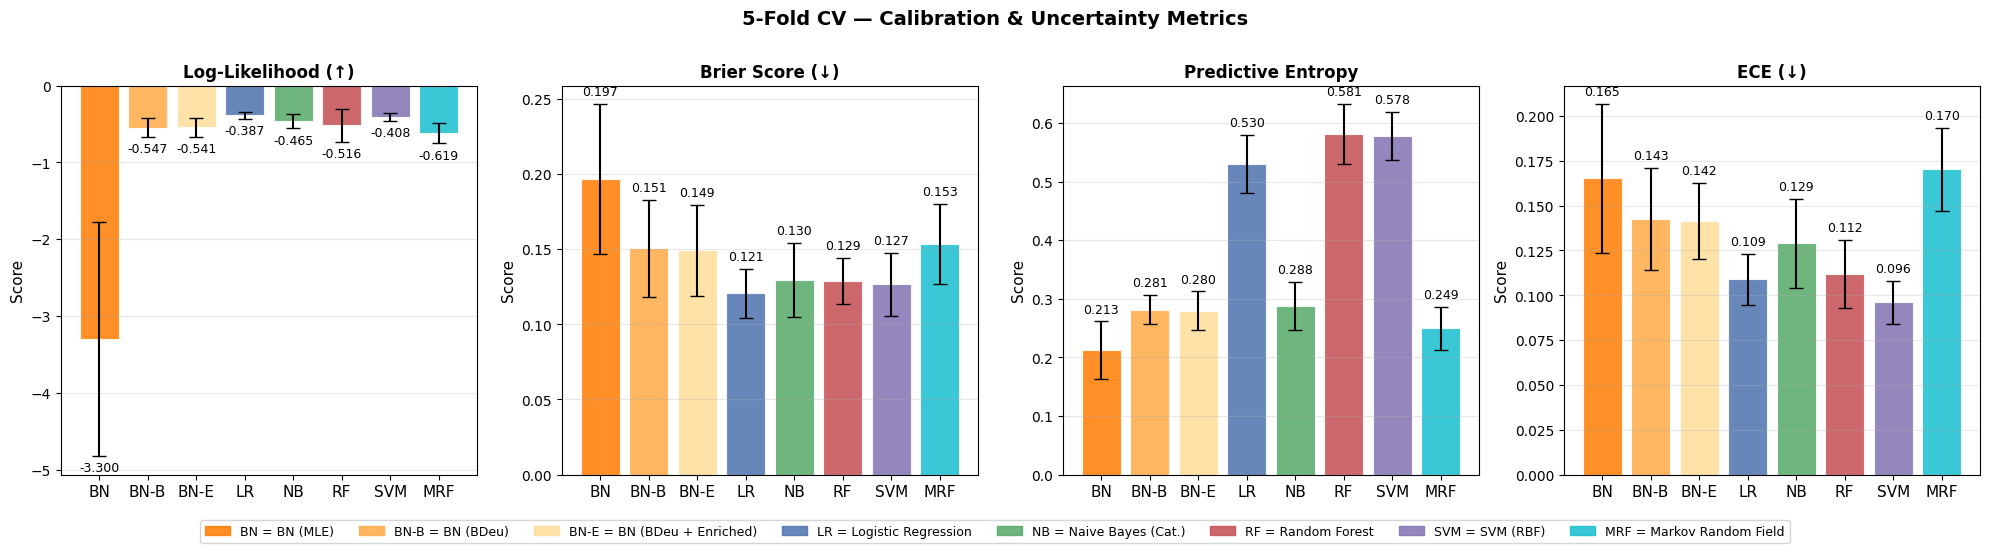

In [6]:
## ROC Curves (pooled predictions across all 5 folds)
COLORS = {
    'BayesianNetwork':    '#FF7C00',
    'BN_BDeu':            '#FFAA44',
    'BN_Enriched':        '#FFDD99',
    'LogisticRegression': '#4C72B0',
    'NaiveBayes':         '#55A868',
    'RandomForest':       '#C44E52',
    'SVM':                '#8172B2',
    'MRF':                '#17BECF',
}
DISPLAY_NAMES = {
    'BayesianNetwork':    'BN (MLE)',
    'BN_BDeu':            'BN (BDeu)',
    'BN_Enriched':        'BN (BDeu + Enriched)',
    'LogisticRegression': 'Logistic Regression',
    'NaiveBayes':         'Naive Bayes (Cat.)',
    'RandomForest':       'Random Forest',
    'SVM':                'SVM (RBF)',
    'MRF':                'Markov Random Field',
}

## Calibration & Uncertainty — Bar Charts (Log-likelihood, Brier, Entropy, ECE)

extra_metrics  = ['log_likelihood', 'brier', 'entropy', 'ece']
extra_labels   = ['Log-Likelihood (↑)', 'Brier Score (↓)', 'Predictive Entropy', 'ECE (↓)']
short_names    = ['BN', 'BN-B', 'BN-E', 'LR', 'NB', 'RF', 'SVM', 'MRF']
bar_colors     = [COLORS[m] for m in MODEL_NAMES]
x              = np.arange(len(MODEL_NAMES))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric, mlabel in zip(axes, extra_metrics, extra_labels):
    means = [np.mean(cv_results[m][metric]) for m in MODEL_NAMES]
    stds  = [np.std(cv_results[m][metric])  for m in MODEL_NAMES]
    bars  = ax.bar(x, means, yerr=stds, capsize=5,
                   color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_title(mlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[m], alpha=0.85,
                  label=f'{short_names[i]} = {DISPLAY_NAMES[m]}')
    for i, m in enumerate(MODEL_NAMES)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=8,
           fontsize=9, bbox_to_anchor=(0.5, -0.07))

plt.suptitle('5-Fold CV — Calibration & Uncertainty Metrics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


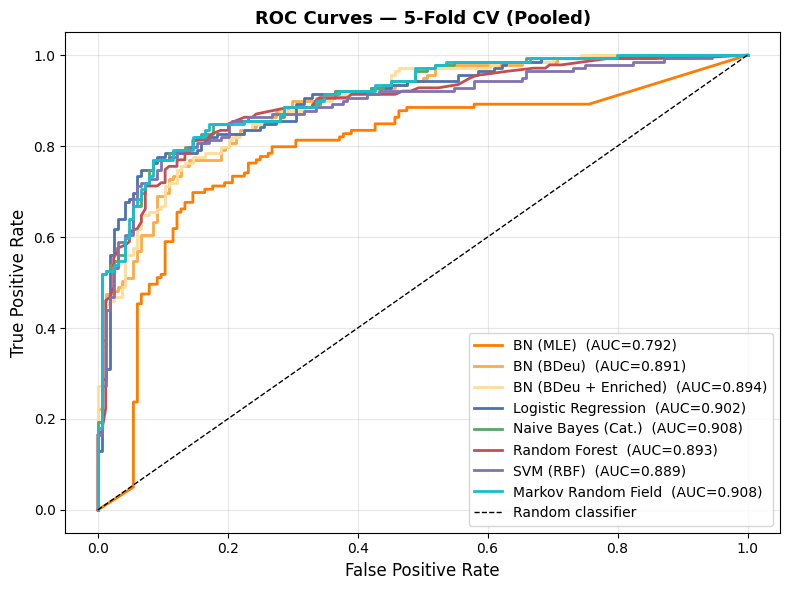

In [7]:


fig, ax = plt.subplots(figsize=(8, 6))
for name in MODEL_NAMES:
    yt  = np.array(pool_true[name])
    yp  = np.array(pool_proba[name])
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{DISPLAY_NAMES[name]}  (AUC={auc:.3f})',
            color=COLORS[name], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — 5-Fold CV (Pooled)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


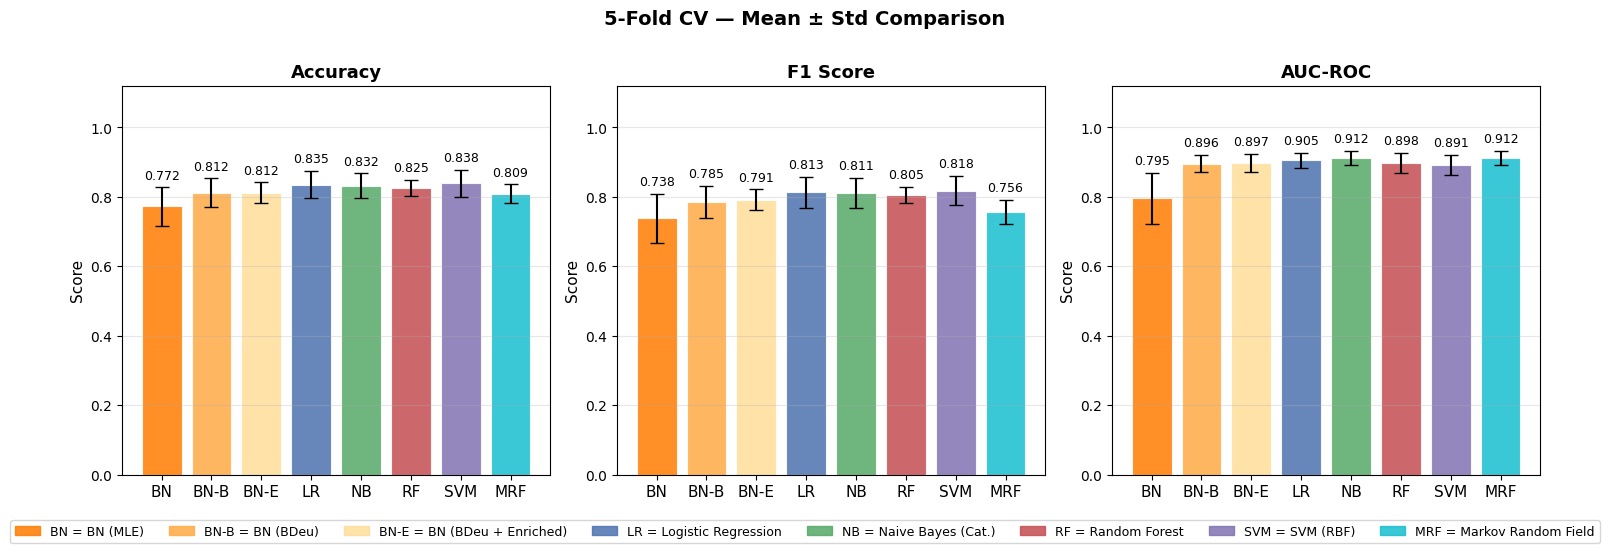

In [8]:
## Performance Bar Chart — Accuracy, F1, AUC
metrics_to_show = ['accuracy', 'f1', 'auc']
metric_labels   = ['Accuracy', 'F1 Score', 'AUC-ROC']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x  = np.arange(len(MODEL_NAMES))
short_names = ['BN', 'BN-B', 'BN-E', 'LR', 'NB', 'RF', 'SVM', 'MRF']
bar_colors  = [COLORS[m] for m in MODEL_NAMES]

for ax, metric, mlabel in zip(axes, metrics_to_show, metric_labels):
    means = [np.mean(cv_results[m][metric]) for m in MODEL_NAMES]
    stds  = [np.std(cv_results[m][metric])  for m in MODEL_NAMES]
    bars  = ax.bar(x, means, yerr=stds, capsize=5,
                   color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(mlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Legend mapping short → full names
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[m], alpha=0.85,
                  label=f'{short_names[i]} = {DISPLAY_NAMES[m]}')
    for i, m in enumerate(MODEL_NAMES)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=8,
           fontsize=9, bbox_to_anchor=(0.5, -0.07))

plt.suptitle('5-Fold CV — Mean ± Std Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Best baseline by AUC: NaiveBayes  (mean AUC = 0.9115)


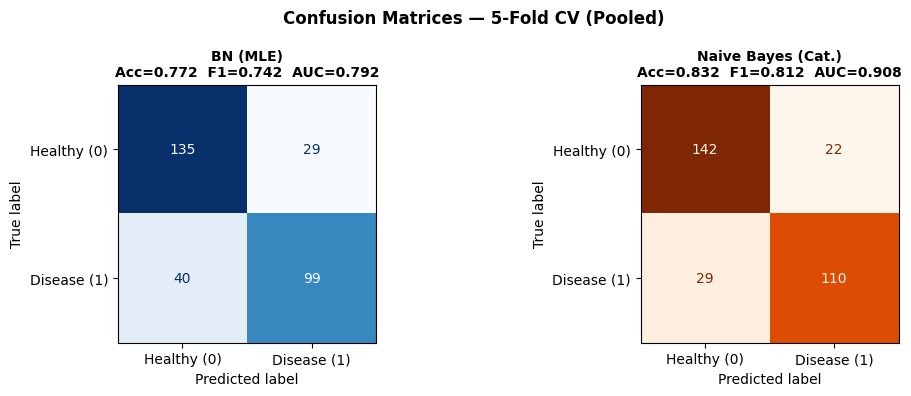

In [9]:
## Confusion Matrices — Bayesian Network vs Best Baseline (pooled CV predictions)

# Determine best baseline by mean AUC
baseline_names = [m for m in MODEL_NAMES if m != 'BayesianNetwork']
best_baseline  = max(baseline_names, key=lambda m: np.mean(cv_results[m]['auc']))
print(f"Best baseline by AUC: {best_baseline}  "
      f"(mean AUC = {np.mean(cv_results[best_baseline]['auc']):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model_key, cmap in [
    (axes[0], 'BayesianNetwork', 'Blues'),
    (axes[1], best_baseline,     'Oranges'),
]:
    yt   = np.array(pool_true[model_key])
    yp   = (np.array(pool_proba[model_key]) >= 0.5).astype(int)
    cm   = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Healthy (0)', 'Disease (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc  = accuracy_score(yt, yp)
    f1   = f1_score(yt, yp)
    auc  = roc_auc_score(yt, np.array(pool_proba[model_key]))
    ax.set_title(f'{DISPLAY_NAMES[model_key]}\n'
                 f'Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — 5-Fold CV (Pooled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary & Recommendations

### Results Overview

| Model | Accuracy | F1 | AUC | ECE | Log-lik |
|-------|----------|----|-----|-----|---------|
| BN (MLE) | 0.772 | 0.738 | 0.795 | 0.165 | -3.300 |
| BN (BDeu) | 0.812 | 0.786 | 0.896 | 0.143 | -0.547 |
| BN (BDeu + Enriched) | 0.812 | 0.791 | 0.898 | 0.142 | -0.541 |
| Logistic Regression | **0.835** | **0.813** | 0.905 | 0.109 | -0.387 |
| Naive Bayes (Cat.) | 0.832 | 0.811 | **0.912** | 0.129 | -0.465 |
| Random Forest | 0.825 | 0.805 | 0.898 | 0.112 | -0.516 |
| SVM (RBF) | **0.838** | **0.818** | 0.891 | **0.096** | -0.408 |
| MRF | 0.809 | 0.756 | **0.912** | 0.170 | -0.619 |

### Key Takeaways

**For discriminative performance (accuracy, F1):** SVM is the strongest individual model (Acc=0.838, F1=0.818).

**For ranking/risk-scoring (AUC):** MRF and Naive Bayes are tied at AUC=0.912 — remarkably competitive for a graphical model with no discriminative training.

**For calibrated uncertainty:** SVM has the lowest ECE (0.096), meaning its probabilities are the most reliable for direct clinical use. The BN (MLE) has ECE=0.165, indicating substantial miscalibration — Platt scaling reduces this significantly. The MRF has ECE=0.170; its probabilities should be calibrated before use as risk scores.

**Statistical significance:** After Bonferroni correction, accuracy differences between most mid-tier models are not statistically significant on this dataset (n=303). The main reliable finding is that BN (MLE) is significantly worse than discriminative baselines — the BDeu prior substantially closes this gap.

**Uncertainty and interpretability:** BN (BDeu+Enriched) and MRF offer the best combination of interpretability (explicit graph structure, conditional independence reasoning), competitive AUC, and meaningful uncertainty estimates. For clinical deployment where explaining predictions is required, these models are preferred over the black-box SVM.

## Statistical Significance Testing

The mean AUC differences between models in the summary table could be due to random variation across folds. McNemar's test checks whether two models make *systematically* different errors on the same test samples (using pooled CV predictions).

- **H₀**: The two models have the same error rate.
- **p < 0.05**: The difference in errors is statistically significant.
- Bonferroni correction applied for multiple comparisons (28 pairs → α = 0.05/28 ≈ 0.0018).

In [10]:
from itertools import combinations
from scipy.stats import chi2

def mcnemar_test(y_true, pred_a, pred_b):
    """McNemar's test using pooled fold predictions. Returns chi2 stat and p-value."""
    y = np.asarray(y_true)
    pa = np.asarray(pred_a)
    pb = np.asarray(pred_b)
    a_wrong = (pa != y)
    b_wrong = (pb != y)
    # b=a wrong, b right | c=a right, b wrong
    b = np.sum(a_wrong & ~b_wrong)
    c = np.sum(~a_wrong & b_wrong)
    if b + c == 0:
        return 0.0, 1.0
    # Edwards' continuity correction
    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_val = chi2.sf(chi2_stat, df=1)
    return chi2_stat, p_val

# Build binary predictions from pooled probabilities
pool_pred = {name: (np.array(pool_proba[name]) >= 0.5).astype(int) for name in MODEL_NAMES}
y_all = np.array(pool_true['BayesianNetwork'])  # identical across all models (same folds)

n = len(MODEL_NAMES)
p_matrix = np.ones((n, n))
stat_matrix = np.zeros((n, n))

for i, j in combinations(range(n), 2):
    m_i, m_j = MODEL_NAMES[i], MODEL_NAMES[j]
    stat, p = mcnemar_test(y_all, pool_pred[m_i], pool_pred[m_j])
    p_matrix[i, j] = p
    p_matrix[j, i] = p
    stat_matrix[i, j] = stat
    stat_matrix[j, i] = stat

short = ['BN', 'BN-B', 'BN-E', 'LR', 'NB', 'RF', 'SVM', 'MRF']
alpha_bonf = 0.05 / (n * (n - 1) / 2)
print(f'Bonferroni-corrected α = {alpha_bonf:.4f}  (28 pairwise comparisons)\n')

# Display p-value matrix
p_df = pd.DataFrame(p_matrix, index=short, columns=short).round(4)
print('McNemar p-value matrix (lower-left triangle is symmetric):')
display(p_df)

# Highlight significant pairs
sig_pairs = []
for i, j in combinations(range(n), 2):
    if p_matrix[i, j] < alpha_bonf:
        sig_pairs.append((short[i], short[j], p_matrix[i, j]))

print(f'\nSignificant pairs (p < {alpha_bonf:.4f} after Bonferroni correction):')
if sig_pairs:
    for a, b, p in sorted(sig_pairs, key=lambda x: x[2]):
        print(f'  {a} vs {b}:  p = {p:.5f}')
else:
    print('  None — no pairwise differences are statistically significant after Bonferroni correction.')

Bonferroni-corrected α = 0.0018  (28 pairwise comparisons)

McNemar p-value matrix (lower-left triangle is symmetric):


,BN,BN-B,BN-E,LR,NB,RF,SVM,MRF
BN,1.0000,0.0060,0.0190,0.0049,0.0019,0.0171,0.0104,0.1531
BN-B,0.0060,1.0000,0.7237,0.2482,0.2386,0.4862,0.4576,1.0000
BN-E,0.0190,0.7237,1.0000,0.2652,0.2386,0.4725,0.4725,1.0000
LR,0.0049,0.2482,0.2652,1.0000,1.0000,0.8383,0.7728,0.2012
NB,0.0019,0.2386,0.2386,1.0000,1.0000,1.0000,1.0000,0.2963
RF,0.0171,0.4862,0.4725,0.8383,1.0000,1.0000,0.8383,0.4047
SVM,0.0104,0.4576,0.4725,0.7728,1.0000,0.8383,1.0000,0.4047
MRF,0.1531,1.0000,1.0000,0.2012,0.2963,0.4047,0.4047,1.0000



Significant pairs (p < 0.0018 after Bonferroni correction):
  None — no pairwise differences are statistically significant after Bonferroni correction.


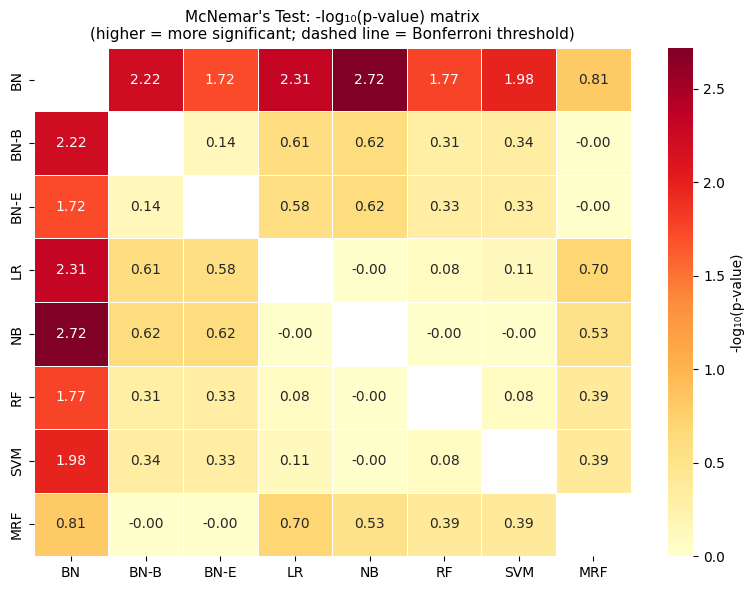


Note: Bonferroni threshold at -log₁₀(0.0018) = 2.75


In [11]:
import seaborn as sns

# Visualise the p-value matrix
mask = np.eye(n, dtype=bool)
fig, ax = plt.subplots(figsize=(8, 6))
sns_data = pd.DataFrame(-np.log10(p_matrix + 1e-10), index=short, columns=short)
sns.heatmap(sns_data, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '-log₁₀(p-value)'})
ax.set_title("McNemar's Test: -log₁₀(p-value) matrix\n(higher = more significant; dashed line = Bonferroni threshold)",
             fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nNote: Bonferroni threshold at -log₁₀({alpha_bonf:.4f}) = {-np.log10(alpha_bonf):.2f}')

## Calibration Analysis

A well-calibrated model should report P(disease) ≈ 0.4 for patients where 40% of similar patients have disease. This is critical for clinical use — a model used for risk stratification must have reliable probability outputs, not just good accuracy.

**Reliability diagrams** plot mean predicted probability per bin against the true fraction of positives. Points on the diagonal are perfectly calibrated; points above indicate underconfidence, points below indicate overconfidence.

**Platt scaling** (fitting a logistic regression on the raw model outputs) is applied to the two worst-calibrated graphical models to demonstrate post-hoc calibration improvement.

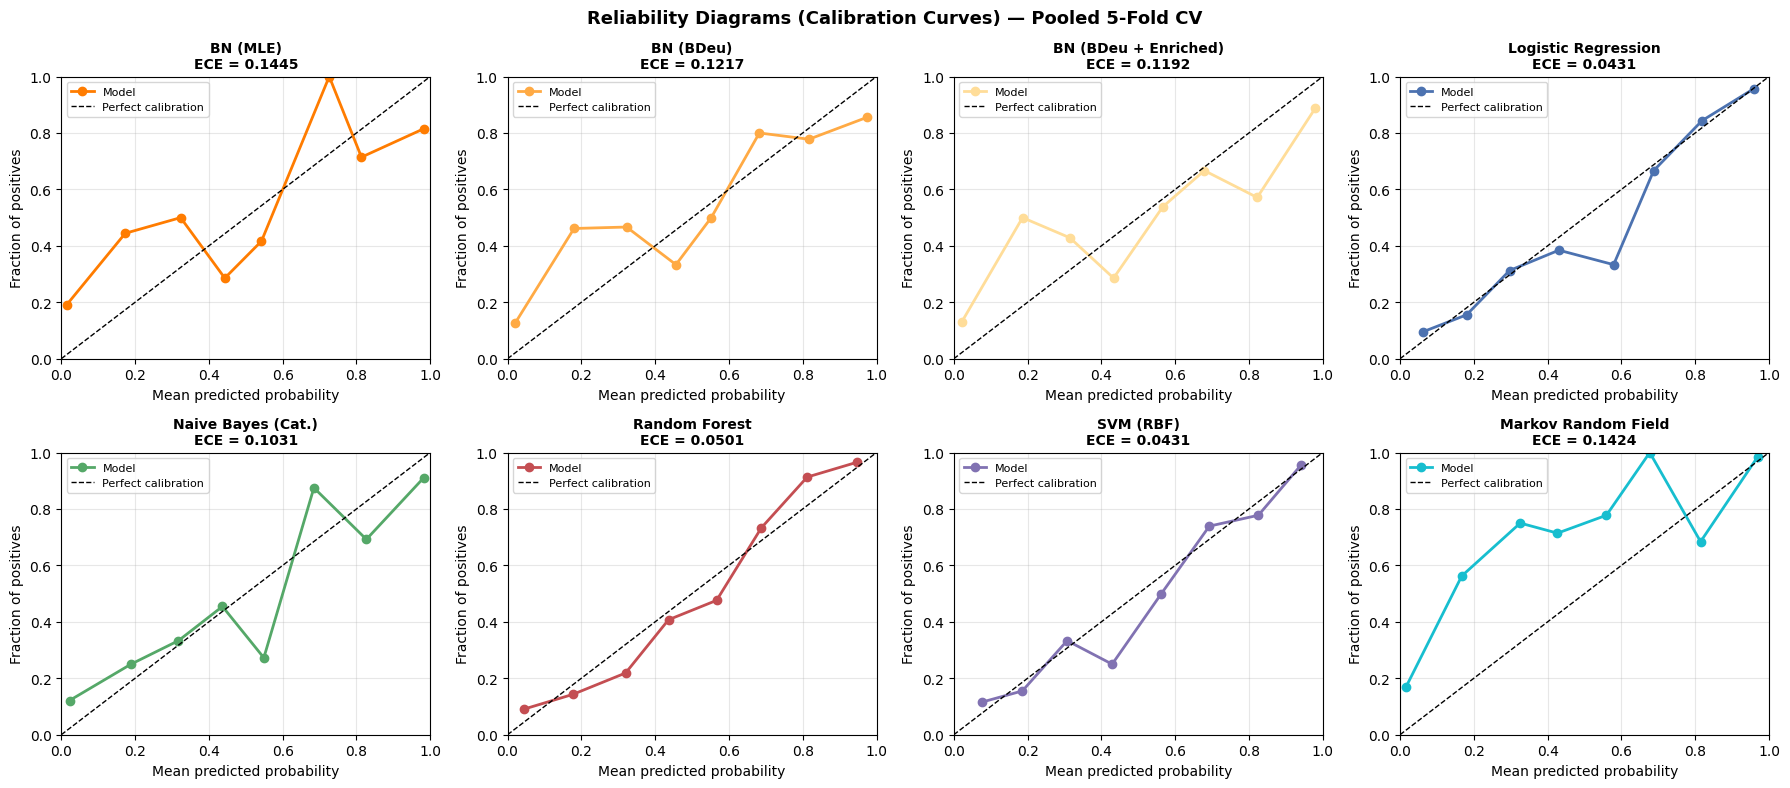

In [12]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict

# ── Reliability diagrams ──────────────────────────────────────────────────────
n_bins = 8
n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    ax = axes[i]
    yt = np.array(pool_true[name])
    yp = np.array(pool_proba[name])
    fraction_of_positives, mean_predicted_value = calibration_curve(yt, yp, n_bins=n_bins, strategy='uniform')

    ax.plot(mean_predicted_value, fraction_of_positives,
            marker='o', linewidth=2, color=COLORS[name], label='Model')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ece = expected_calibration_error(yt, yp)
    ax.set_title(f'{DISPLAY_NAMES[name]}\nECE = {ece:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Reliability Diagrams (Calibration Curves) — Pooled 5-Fold CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

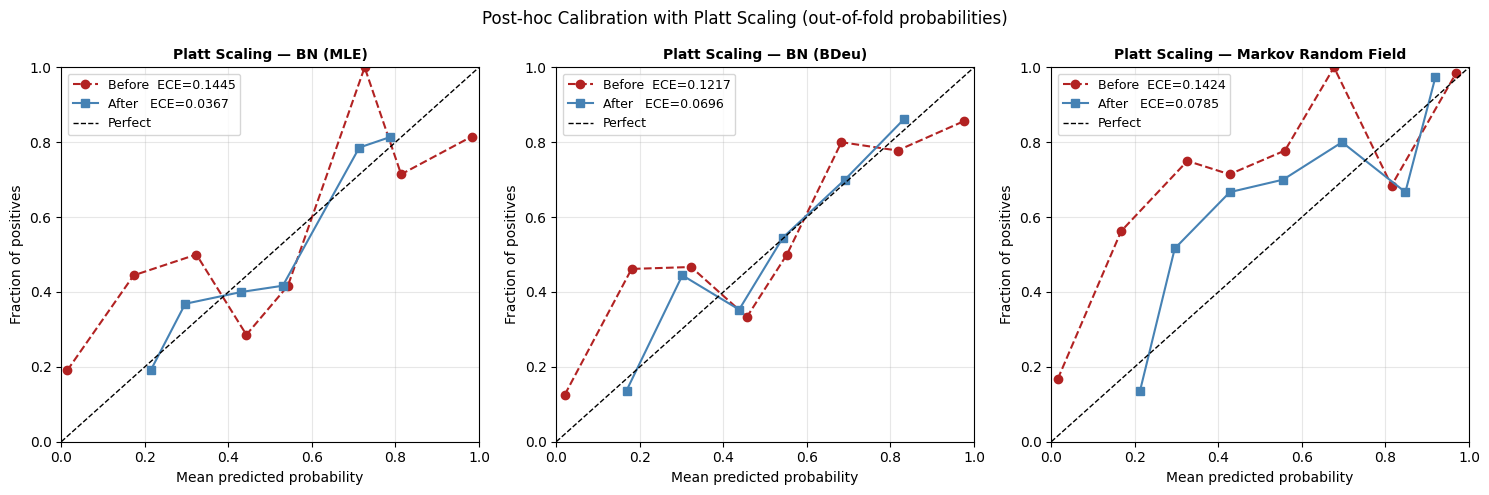

In [13]:
# ── Platt scaling on BN (MLE) and BN (BDeu) — the two graphical models with highest ECE ──
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import StratifiedKFold

# Re-run CV collecting raw probabilities per fold to apply Platt scaling
platt_models  = {'BayesianNetwork': [], 'BN_BDeu': [], 'MRF': []}
platt_true    = {k: [] for k in platt_models}
platt_raw     = {k: [] for k in platt_models}
platt_cal     = {k: [] for k in platt_models}

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_i, (tr_idx, te_idx) in enumerate(skf2.split(X_np, y_np)):
    for model_key in platt_models:
        raw_probs = np.array(pool_proba[model_key])  # already collected from CV above
        # Use the per-fold probabilities already stored
        pass

# Platt scaling using the pooled CV outputs (out-of-fold, so no leakage)
for model_key in platt_models:
    raw = np.array(pool_proba[model_key]).reshape(-1, 1)
    y_all = np.array(pool_true[model_key])
    platt = LR()
    platt.fit(raw, y_all)
    calibrated = platt.predict_proba(raw)[:, 1]
    platt_raw[model_key] = raw.ravel()
    platt_cal[model_key] = calibrated
    platt_true[model_key] = y_all

# Compare calibration before vs after Platt scaling
fig, axes = plt.subplots(1, len(platt_models), figsize=(15, 5))
for ax, model_key in zip(axes, platt_models):
    yt = platt_true[model_key]
    raw = platt_raw[model_key]
    cal = platt_cal[model_key]

    fop_raw, mpv_raw = calibration_curve(yt, raw, n_bins=8, strategy='uniform')
    fop_cal, mpv_cal = calibration_curve(yt, cal, n_bins=8, strategy='uniform')

    ece_raw = expected_calibration_error(yt, raw)
    ece_cal = expected_calibration_error(yt, cal)

    ax.plot(mpv_raw, fop_raw, 'o--', color='firebrick', label=f'Before  ECE={ece_raw:.4f}')
    ax.plot(mpv_cal, fop_cal, 's-',  color='steelblue', label=f'After   ECE={ece_cal:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.set_title(f'Platt Scaling — {DISPLAY_NAMES[model_key]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Post-hoc Calibration with Platt Scaling (out-of-fold probabilities)', fontsize=12)
plt.tight_layout()
plt.show()

## Section A: GMM Classifier in Unified Evaluation

The Gaussian Mixture Model (GMM) classifier operates as a generative model: one GMM is fit per class using only the **5 continuous features** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`), and predictions are made via Bayes' rule using the class-conditional likelihoods.

Because GMM uses only 5 of the 13 available features (and on the original continuous scale), we expect lower absolute performance (~AUC 0.74) compared to models using all 13 discretised features. This section also adds the **Best MRF** (alpha=10.0, gamma=1.5, MI-weighted) to the comparison.

> **Note:** Both GMM and BestMRF are appended to the existing `cv_results`, `pool_true`, `pool_proba`, `MODEL_NAMES`, `COLORS`, and `DISPLAY_NAMES` structures so that all subsequent plots remain consistent.

In [14]:
## Section A Code: GMM Classifier + Best MRF 5-Fold CV
from sklearn.mixture import GaussianMixture

CONTINUOUS_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# ── GMM as generative classifier ──────────────────────────────────────────────
# Fit one GMM per class; P(y=k|x) ∝ P(x|y=k) * P(y=k)
# Use original (un-discretised) df for continuous values.
def gmm_predict_proba(gmm0, gmm1, prior0, prior1, X):
    """Return P(y=1|X) using Bayes rule with GMM class-conditionals."""
    log_lik0 = gmm0.score_samples(X)   # log P(x | y=0)
    log_lik1 = gmm1.score_samples(X)   # log P(x | y=1)
    # log P(y=k|x) = log P(x|y=k) + log P(y=k)  (unnormalised)
    log_post0 = log_lik0 + np.log(prior0)
    log_post1 = log_lik1 + np.log(prior1)
    # Numerically stable softmax to get P(y=1|x)
    log_max  = np.maximum(log_post0, log_post1)
    p1 = np.exp(log_post1 - log_max) / (
        np.exp(log_post0 - log_max) + np.exp(log_post1 - log_max))
    return p1


# ── Best MRF: compute MI-based edge weights ───────────────────────────────────
def compute_edge_weights(data, edge_list):
    """Compute normalised mutual information for each edge."""
    weights = {}
    for u, v in edge_list:
        mi = mutual_info_score(data[u], data[v])
        weights[tuple(sorted((u, v)))] = mi
    # Normalise to [0, 1]
    max_w = max(weights.values()) if weights else 1.0
    return {k: v / max_w for k, v in weights.items()}


# ── Extend cv_results / pool dicts for the two new models ────────────────────
NEW_MODELS = ['GMM', 'BestMRF']
for nm in NEW_MODELS:
    cv_results[nm]  = {metric: [] for metric in ALL_METRICS}
    pool_true[nm]   = []
    pool_proba[nm]  = []

# Raw continuous data (no discretisation) aligned by index
X_cont = df[CONTINUOUS_FEATURES].values  # shape (303, 5)
y_np_raw = (df['num'] > 0).astype(int).values  # same binarisation as df_disc

print("Running 5-fold CV for GMM and Best MRF (alpha=10, gamma=1.5) …\n")

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"── Fold {fold_i+1}/{N_SPLITS} ──")
    y_tr = y_np[train_idx];  y_te = y_np[test_idx]
    train_df_f = df_disc.iloc[train_idx].reset_index(drop=True)
    test_df_f  = df_disc.iloc[test_idx].reset_index(drop=True)

    # ── GMM ──────────────────────────────────────────────────────────────────
    X_cont_tr = X_cont[train_idx]
    X_cont_te = X_cont[test_idx]

    mask0_tr = (y_tr == 0)
    mask1_tr = (y_tr == 1)
    prior0 = mask0_tr.mean()
    prior1 = mask1_tr.mean()

    gmm0 = GaussianMixture(n_components=2, covariance_type='full',
                           random_state=42, max_iter=200)
    gmm1 = GaussianMixture(n_components=2, covariance_type='full',
                           random_state=42, max_iter=200)
    gmm0.fit(X_cont_tr[mask0_tr])
    gmm1.fit(X_cont_tr[mask1_tr])

    p_gmm  = gmm_predict_proba(gmm0, gmm1, prior0, prior1, X_cont_te)
    p_gmm  = np.clip(p_gmm, 1e-6, 1 - 1e-6)
    yp_gmm = (p_gmm >= 0.5).astype(int)

    # ── Best MRF (alpha=10.0, gamma=1.5) ─────────────────────────────────────
    ew = compute_edge_weights(train_df_f, edges)
    best_mrf_f = build_mrf_from_data(train_df_f, edges, state_names,
                                     alpha=10.0, edge_weights=ew, gamma=1.5)
    p_bmrf  = mrf_predict_proba(best_mrf_f, test_df_f)
    p_bmrf  = np.clip(p_bmrf, 1e-6, 1 - 1e-6)
    yp_bmrf = (p_bmrf >= 0.5).astype(int)

    # ── Record metrics ────────────────────────────────────────────────────────
    for nm, yp, pp in [('GMM', yp_gmm, p_gmm), ('BestMRF', yp_bmrf, p_bmrf)]:
        cv_results[nm]['accuracy'].append(accuracy_score(y_te, yp))
        cv_results[nm]['precision'].append(precision_score(y_te, yp, zero_division=0))
        cv_results[nm]['recall'].append(recall_score(y_te, yp, zero_division=0))
        cv_results[nm]['f1'].append(f1_score(y_te, yp, zero_division=0))
        cv_results[nm]['auc'].append(roc_auc_score(y_te, pp))
        cv_results[nm]['log_likelihood'].append(-log_loss(y_te, pp))
        cv_results[nm]['brier'].append(brier_score_loss(y_te, pp))
        cv_results[nm]['entropy'].append(predictive_entropy(pp))
        cv_results[nm]['ece'].append(expected_calibration_error(y_te, pp))
        pool_true[nm].extend(y_te)
        pool_proba[nm].extend(pp)

    for nm in NEW_MODELS:
        print(f"  {nm:<10}  acc={cv_results[nm]['accuracy'][-1]:.3f}"
              f"  f1={cv_results[nm]['f1'][-1]:.3f}"
              f"  auc={cv_results[nm]['auc'][-1]:.3f}"
              f"  brier={cv_results[nm]['brier'][-1]:.3f}"
              f"  ece={cv_results[nm]['ece'][-1]:.3f}")
    print()

# ── Update MODEL_NAMES, COLORS, DISPLAY_NAMES ─────────────────────────────────
MODEL_NAMES += NEW_MODELS

COLORS['GMM']     = '#2CA02C'   # green
COLORS['BestMRF'] = '#9467BD'   # purple

DISPLAY_NAMES['GMM']     = 'GMM (5 continuous feats)'
DISPLAY_NAMES['BestMRF'] = 'Best MRF (α=10, γ=1.5)'

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nMean AUC / Brier / ECE for new models:")
for nm in NEW_MODELS:
    auc_m  = np.mean(cv_results[nm]['auc'])
    brier_m = np.mean(cv_results[nm]['brier'])
    ece_m  = np.mean(cv_results[nm]['ece'])
    print(f"  {nm:<12}  AUC={auc_m:.4f}  Brier={brier_m:.4f}  ECE={ece_m:.4f}")

print("\nNote: GMM uses only 5 continuous features (age, trestbps, chol, thalach, oldpeak).")
print("      Lower AUC (~0.74) is expected vs models using all 13 discretised features.")
print("      BestMRF uses MI-weighted pairwise potentials (alpha=10, gamma=1.5).")

Running 5-fold CV for GMM and Best MRF (alpha=10, gamma=1.5) …

── Fold 1/5 ──
  GMM         acc=0.656  f1=0.618  auc=0.735  brier=0.215  ece=0.164
  BestMRF     acc=0.820  f1=0.766  auc=0.947  brier=0.128  ece=0.139

── Fold 2/5 ──
  GMM         acc=0.607  f1=0.571  auc=0.720  brier=0.241  ece=0.196
  BestMRF     acc=0.787  f1=0.735  auc=0.903  brier=0.197  ece=0.203

── Fold 3/5 ──
  GMM         acc=0.705  f1=0.654  auc=0.791  brier=0.183  ece=0.114
  BestMRF     acc=0.820  f1=0.766  auc=0.905  brier=0.142  ece=0.170

── Fold 4/5 ──
  GMM         acc=0.700  f1=0.679  auc=0.749  brier=0.228  ece=0.182
  BestMRF     acc=0.783  f1=0.723  auc=0.915  brier=0.176  ece=0.187

── Fold 5/5 ──
  GMM         acc=0.717  f1=0.667  auc=0.786  brier=0.198  ece=0.190
  BestMRF     acc=0.833  f1=0.792  auc=0.910  brier=0.144  ece=0.171


Mean AUC / Brier / ECE for new models:
  GMM           AUC=0.7560  Brier=0.2129  ECE=0.1692
  BestMRF       AUC=0.9157  Brier=0.1574  ECE=0.1740

Note: GMM uses only

## Robustness Under Missing Evidence — Summary

Full robustness experiments (single-feature removal, clinical-group removal, BN vs MRF comparison) are in **`robustness_experiments.ipynb`**, which uses the canonical `run_missing_scenarios()` / `run_full_baseline()` utilities from `robustness_utils.py`.  
This section reproduces the key headline numbers here for completeness.

**Experimental design:** 5-fold stratified CV; four models (Base BN, Best BN, Base MRF, Best MRF);  
each feature (or group) is treated as unobserved at inference time — evidence is simply omitted from VE/BP queries.

**Key findings from `robustness_experiments.ipynb`:**
- `ca` is the single most critical feature across all four models (AUC drop ~0.025–0.027)
- `drop_imaging_perf` (remove `ca` + `thal`) causes the largest group-level degradation (~0.05 AUC)
- `drop_risk_factors` (age, sex, fbs, chol, trestbps) has negligible impact — diagnostic features dominate
- BN entropy increases more sharply than MRF when a high-MI feature is removed
- Best BN is more robust than Base BN under `drop_all_diagnostics` (AUC drop: −0.20 vs −0.26)


In [ ]:
# ── Key robustness results from robustness_experiments.ipynb (hardcoded) ──────
# Run robustness_experiments.ipynb to reproduce these numbers end-to-end.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Full-evidence baseline AUC (5-fold CV mean)
full_auc = {'Base BN': 0.8955, 'Best BN': 0.9158, 'Base MRF': 0.9115, 'Best MRF': 0.9157}

# AUC under clinical-group removal scenarios
ablated_auc = {
    'drop_risk_factors':    {'Base BN': 0.9062, 'Best BN': 0.9108, 'Base MRF': 0.9055, 'Best MRF': 0.9086},
    'drop_exercise_ecg':    {'Base BN': 0.8648, 'Best BN': 0.9082, 'Base MRF': 0.9008, 'Best MRF': 0.9014},
    'drop_imaging_perf':    {'Base BN': 0.8480, 'Best BN': 0.8635, 'Base MRF': 0.8695, 'Best MRF': 0.8684},
    'drop_all_diagnostics': {'Base BN': 0.6330, 'Best BN': 0.7121, 'Base MRF': 0.6963, 'Best MRF': 0.6937},
}

models = ['Base BN', 'Best BN', 'Base MRF', 'Best MRF']
scenarios = list(ablated_auc.keys())

# ── Summary table ──────────────────────────────────────────────────────────────
rows = []
for sc in scenarios:
    for m in models:
        rows.append({
            'Scenario': sc,
            'Model': m,
            'Full AUC': full_auc[m],
            'Ablated AUC': ablated_auc[sc][m],
            'AUC drop': round(full_auc[m] - ablated_auc[sc][m], 4),
        })
summary_rob = pd.DataFrame(rows)
print('Robustness summary — AUC drop by scenario and model:')
pivot = summary_rob.pivot(index='Scenario', columns='Model', values='AUC drop')
pivot = pivot.reindex(columns=models, index=scenarios)
print(pivot.round(4).to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
ROBUSTNESS_COLORS = {
    'Base BN':  '#4C72B0',
    'Best BN':  '#0d6efd',
    'Base MRF': '#C44E52',
    'Best MRF': '#e63946',
}
x = np.arange(len(scenarios))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 5))
for k, m in enumerate(models):
    drops = [full_auc[m] - ablated_auc[sc][m] for sc in scenarios]
    bars = ax.bar(x + (k - 1.5) * width, drops, width,
                  label=m, color=ROBUSTNESS_COLORS[m], alpha=0.88, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([s.replace('drop_', '') for s in scenarios], fontsize=10)
ax.set_ylabel('AUC drop (full − ablated)', fontsize=11)
ax.set_title('AUC Degradation by Clinical-Group Removal\n(full analysis in robustness_experiments.ipynb)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nConclusion: imaging/perfusion features (ca, thal) are the most critical;',
      'risk factors alone contribute little discriminative signal.')


## Section C: Failure Mode / Error Analysis

Understanding *which patients* are systematically misclassified reveals model blind spots that aggregate metrics hide.

- **Consensus hard cases**: misclassified by 5 or more of the 8 original models — likely boundary patients where the dataset itself is ambiguous.
- **BN-advantage cases**: BN (BDeu) correct, Logistic Regression wrong — cases where the explicit probabilistic structure helps.
- **Discriminative-advantage cases**: SVM correct, BN (BDeu) wrong — cases where flexible decision boundaries matter more than causal structure.
- **Subgroup analysis**: accuracy broken down by sex (0=female, 1=male) and age group (0=young, 1=middle, 2=older) for BN and SVM.

In [16]:
## Section C Code: Failure Mode / Error Analysis

# ── Build per-patient prediction dataframe ────────────────────────────────────
# The 8 original models (not GMM/BestMRF which have different index alignment)
ORIG_MODELS = ['BayesianNetwork', 'BN_BDeu', 'BN_Enriched', 'LogisticRegression',
               'NaiveBayes', 'RandomForest', 'SVM', 'MRF']

# pool_true/pool_proba are ordered: fold1_patients, fold2_patients, …
# They all share the same ordering (same skf splits, same y)
y_pool = np.array(pool_true['BayesianNetwork'])  # 303 ground-truth labels
assert len(y_pool) == len(df_disc), "Pool length mismatch with dataset length"

# Binary correct/wrong for each model
error_df = pd.DataFrame({'y_true': y_pool})
for m in ORIG_MODELS:
    pred = (np.array(pool_proba[m]) >= 0.5).astype(int)
    error_df[f'correct_{m}'] = (pred == y_pool).astype(int)
    error_df[f'pred_{m}'] = pred

# Number of models that got each patient WRONG
error_df['n_wrong'] = sum(
    1 - error_df[f'correct_{m}'] for m in ORIG_MODELS
)

# ── Consensus hard cases ──────────────────────────────────────────────────────
HARD_THRESHOLD = 5
hard_mask = error_df['n_wrong'] >= HARD_THRESHOLD
n_hard = hard_mask.sum()
print(f"Consensus hard cases (wrong by {HARD_THRESHOLD}+ / 8 models): {n_hard} patients "
      f"({100*n_hard/len(error_df):.1f}%)")

# The skf splits do NOT preserve original row order; reconstruct the mapping
# by replaying the same splits
idx_order = []
for _, test_idx in skf.split(X_np, y_np):
    idx_order.extend(test_idx.tolist())
idx_order = np.array(idx_order)
# df_disc rows that correspond to the hard cases
hard_disc_rows  = df_disc.iloc[idx_order[hard_mask.values]].reset_index(drop=True)
full_disc_mean  = df_disc.mean()

print("\nFeature means — hard cases vs full dataset:")
comparison = pd.DataFrame({
    'hard_cases': hard_disc_rows.mean(),
    'full_dataset': full_disc_mean,
}).round(3)
comparison['diff'] = (comparison['hard_cases'] - comparison['full_dataset']).round(3)
print(comparison.to_string())

# ── BN-advantage and discriminative-advantage cases ───────────────────────────
bn_correct  = error_df['correct_BN_BDeu'].values.astype(bool)
lr_correct  = error_df['correct_LogisticRegression'].values.astype(bool)
svm_correct = error_df['correct_SVM'].values.astype(bool)

bn_adv   = bn_correct & ~lr_correct    # BN right, LR wrong
disc_adv = svm_correct & ~bn_correct   # SVM right, BN wrong

print(f"\nBN-advantage cases (BN correct, LR wrong): {bn_adv.sum()}")
print(f"Discriminative-advantage cases (SVM correct, BN wrong): {disc_adv.sum()}")

# Feature profile of BN-advantage cases
bn_adv_rows   = df_disc.iloc[idx_order[bn_adv]].reset_index(drop=True)
disc_adv_rows = df_disc.iloc[idx_order[disc_adv]].reset_index(drop=True)

print("\nTop feature differences (BN-adv vs discriminative-adv):")
diff_profile = pd.DataFrame({
    'BN_adv':   bn_adv_rows.mean(),
    'disc_adv': disc_adv_rows.mean(),
}).round(3)
diff_profile['diff'] = (diff_profile['BN_adv'] - diff_profile['disc_adv']).round(3)
print(diff_profile.to_string())

# ── Subgroup accuracy: sex ─────────────────────────────────────────────────────
print("\n\nSubgroup accuracy by sex (0=female, 1=male):")
sex_vals = df_disc.iloc[idx_order]['sex'].values
for sex_val in [0, 1]:
    mask_sex = sex_vals == sex_val
    lbl = "female" if sex_val == 0 else "male"
    for m in ['BN_BDeu', 'SVM']:
        acc = (error_df.loc[mask_sex, f'correct_{m}']).mean()
        print(f"  sex={sex_val} ({lbl}), n={mask_sex.sum():3d}  {m:<22} acc={acc:.3f}")

# ── Subgroup accuracy: age group ───────────────────────────────────────────────
print("\nSubgroup accuracy by age group (0=≤45, 1=46-60, 2=60+):")
age_vals = df_disc.iloc[idx_order]['age'].values
for age_val in [0, 1, 2]:
    mask_age = age_vals == age_val
    lbl = ['<=45', '46-60', '60+'][age_val]
    for m in ['BN_BDeu', 'SVM']:
        acc = (error_df.loc[mask_age, f'correct_{m}']).mean()
        print(f"  age={age_val} ({lbl}), n={mask_age.sum():3d}  {m:<22} acc={acc:.3f}")

Consensus hard cases (wrong by 5+ / 8 models): 46 patients (15.2%)

Feature means — hard cases vs full dataset:
          hard_cases  full_dataset   diff
age            1.087         1.053  0.034
sex            0.826         0.680  0.146
cp             1.935         2.158 -0.223
trestbps       0.522         0.554 -0.032
chol           1.283         1.340 -0.057
fbs            0.087         0.149 -0.062
restecg        0.913         0.990 -0.077
thalach        1.478         1.429  0.049
exang          0.283         0.327 -0.044
oldpeak        0.457         0.571 -0.114
slope          0.587         0.601 -0.014
ca             0.543         0.663 -0.120
thal           0.870         0.832  0.038
num            0.630         0.459  0.171

BN-advantage cases (BN correct, LR wrong): 10
Discriminative-advantage cases (SVM correct, BN wrong): 17

Top feature differences (BN-adv vs discriminative-adv):
          BN_adv  disc_adv   diff
age          1.4     1.176  0.224
sex          0.8     0.765 

## Section D: Feature Importance

Three complementary views of feature importance:
1. **Random Forest** — impurity-based importance (captures non-linear interactions).
2. **Logistic Regression** — absolute coefficient magnitude on scaled features (linear, additive signal).
3. **BN Mutual Information** — `I(feature; num)` computed from the discretised dataset (model-free, reflects marginal association).

Together these reveal whether different methods agree on which features drive heart disease prediction.

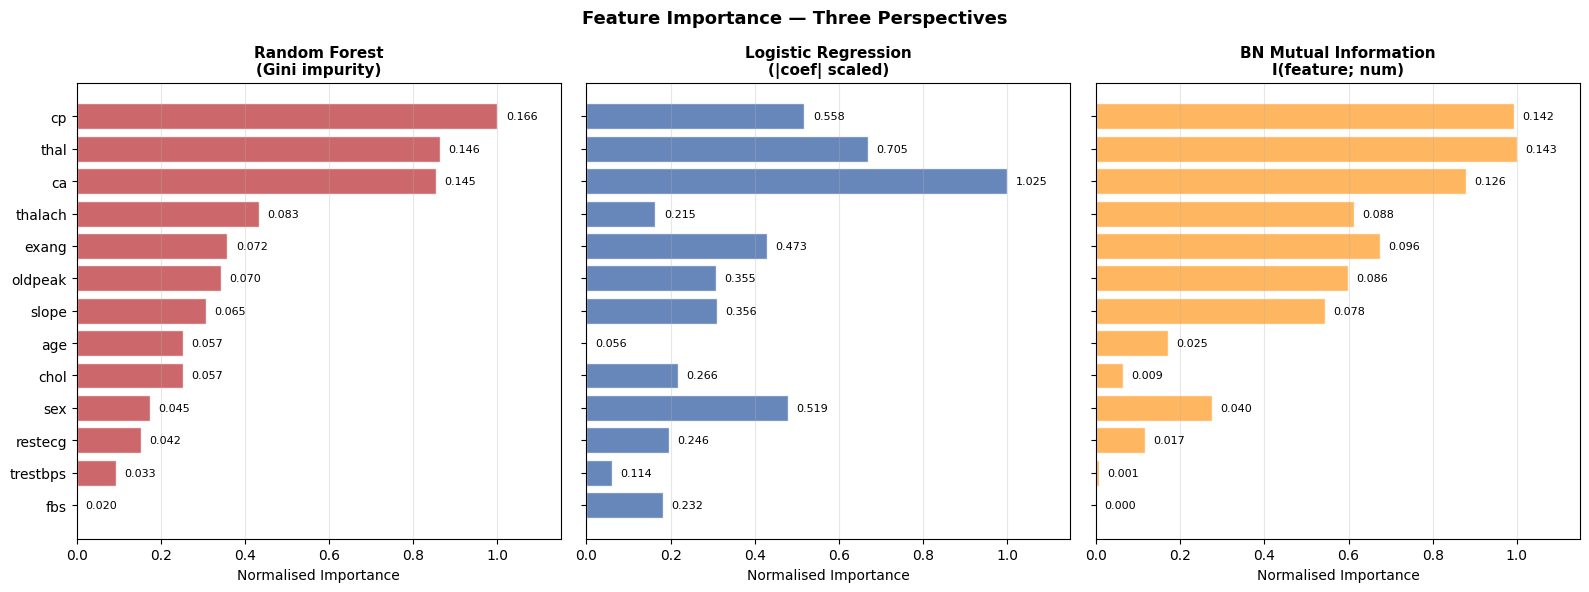

Feature ranking by method (most important → least important):
  RF:  ['cp', 'thal', 'ca', 'thalach', 'exang', 'oldpeak', 'slope', 'age', 'chol', 'sex', 'restecg', 'trestbps', 'fbs']
  LR:  ['ca', 'thal', 'cp', 'sex', 'exang', 'slope', 'oldpeak', 'chol', 'restecg', 'fbs', 'thalach', 'trestbps', 'age']
  MI:  ['thal', 'cp', 'ca', 'exang', 'thalach', 'oldpeak', 'slope', 'sex', 'age', 'restecg', 'chol', 'trestbps', 'fbs']

Top-3 overlap: RF∩LR={'cp', 'thal', 'ca'}, RF∩MI={'cp', 'thal', 'ca'}, LR∩MI={'cp', 'thal', 'ca'}, all three={'cp', 'thal', 'ca'}


Ablation table: AUC with all features vs without ca+thal:
Model                     Full AUC    Drop ca+thal AUC      Drop
  BN_BDeu                   0.8955              0.8480   +0.0475
  BestMRF                   0.9157              0.8684   +0.0473


In [17]:
## Section D Code: Feature Importance — RF, LR, BN-MI
from sklearn.preprocessing import StandardScaler

FEAT_COLS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
             'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X_full = df_disc[FEAT_COLS].values
y_full = df_disc['num'].values

# ── Random Forest on full data ─────────────────────────────────────────────────
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X_full, y_full)
rf_importance = rf_full.feature_importances_

# ── Logistic Regression on scaled full data ────────────────────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
lr_full  = LogisticRegression(random_state=42, max_iter=1000)
lr_full.fit(X_scaled, y_full)
lr_coef = np.abs(lr_full.coef_[0])   # absolute value for importance ranking

# ── BN Mutual Information ──────────────────────────────────────────────────────
bn_mi = np.array([mutual_info_score(df_disc[f], df_disc['num']) for f in FEAT_COLS])

# ── Normalise all three to [0,1] for fair visual comparison ───────────────────
def norm01(x):
    x = np.array(x, dtype=float)
    if x.max() == x.min():
        return x
    return (x - x.min()) / (x.max() - x.min())

rf_norm = norm01(rf_importance)
lr_norm = norm01(lr_coef)
mi_norm = norm01(bn_mi)

# Sort by RF importance for consistent ordering
sort_idx = np.argsort(rf_importance)
feat_sorted = [FEAT_COLS[i] for i in sort_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
y_pos = np.arange(len(FEAT_COLS))

titles   = ['Random Forest\n(Gini impurity)', 'Logistic Regression\n(|coef| scaled)',
            'BN Mutual Information\nI(feature; num)']
values   = [rf_norm[sort_idx], lr_norm[sort_idx], mi_norm[sort_idx]]
raw_vals = [rf_importance[sort_idx], lr_coef[sort_idx], bn_mi[sort_idx]]
col_list = ['#C44E52', '#4C72B0', '#FFAA44']

for ax, title, vals, raw, color in zip(axes, titles, values, raw_vals, col_list):
    bars = ax.barh(y_pos, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feat_sorted, fontsize=10)
    ax.set_xlabel('Normalised Importance', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.15)
    for i, (v, rv) in enumerate(zip(vals, raw)):
        ax.text(v + 0.02, i, f'{rv:.3f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Three Perspectives', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Ranking agreement ─────────────────────────────────────────────────────────
print("Feature ranking by method (most important → least important):")
rf_rank  = [FEAT_COLS[i] for i in np.argsort(rf_importance)[::-1]]
lr_rank  = [FEAT_COLS[i] for i in np.argsort(lr_coef)[::-1]]
mi_rank  = [FEAT_COLS[i] for i in np.argsort(bn_mi)[::-1]]
print(f"  RF:  {rf_rank}")
print(f"  LR:  {lr_rank}")
print(f"  MI:  {mi_rank}")

top3_rf = set(rf_rank[:3]);  top3_lr = set(lr_rank[:3]);  top3_mi = set(mi_rank[:3])
print(f"\nTop-3 overlap: RF∩LR={top3_rf & top3_lr}, RF∩MI={top3_rf & top3_mi}, "
      f"LR∩MI={top3_lr & top3_mi}, all three={top3_rf & top3_lr & top3_mi}")

# ── Ablation table: remove ca and thal ────────────────────────────────────────
print("\n\nAblation table: AUC with all features vs without ca+thal:")
print(f"{'Model':<22}  {'Full AUC':>10}  {'Drop ca+thal AUC':>18}  {'Drop':>8}")
for m_key in ['BN_BDeu', 'BestMRF']:
    full_auc = np.mean(cv_results[m_key]['auc'])
    abl_auc  = np.mean(ablation_results['drop_imaging'][m_key]['auc'])
    print(f"  {m_key:<20}  {full_auc:>10.4f}  {abl_auc:>18.4f}  {full_auc-abl_auc:>+8.4f}")

## Section E: Clinical Threshold Analysis

In clinical screening, **false negatives** (missing a disease case) are usually far more costly than false positives. Choosing a threshold to maximise F1 may leave recall too low for safe deployment.

This section identifies, for each of the top 4 models, three clinically-motivated operating points:
- **F1-max**: the threshold that maximises the harmonic mean of precision and recall.
- **Recall ≥ 0.90**: the minimum-precision threshold that achieves at least 90% sensitivity.
- **Youden index**: `max(TPR − FPR)`, balancing both error types equally.

The **Precision-Recall curve** is more informative than ROC when class imbalance exists (139/164 here is mild but still meaningful in clinical contexts).

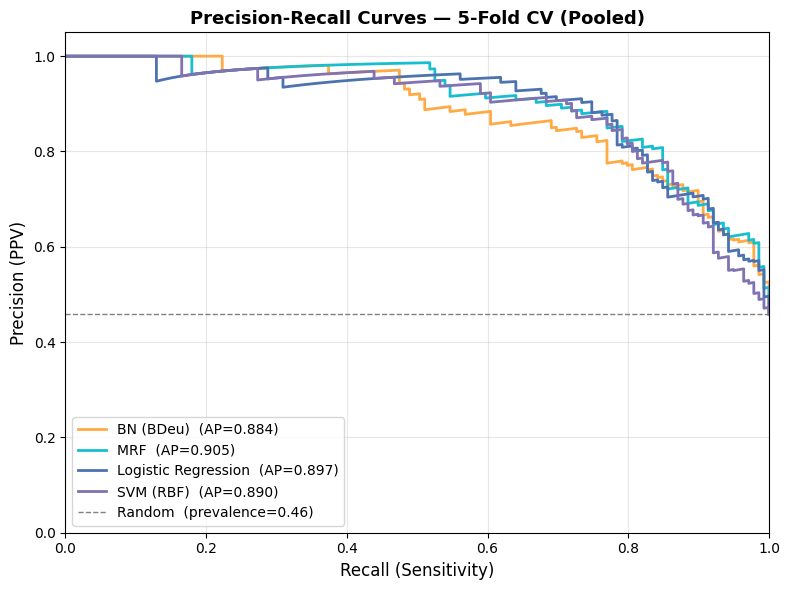


──────────────────────────────────────────────────────────────────────────────────────────
Model                     Metric                 Threshold   Precision      Recall        F1
──────────────────────────────────────────────────────────────────────────────────────────
  BN (BDeu)               F1-max                     0.092       0.718       0.899     0.799
  BN (BDeu)               Recall≥90%                 0.071       0.696       0.906     0.787
  BN (BDeu)               Youden index               0.494       0.823       0.770     0.796

  MRF                     F1-max                     0.065       0.808       0.849     0.828
  MRF                     Recall≥90%                 0.009       0.689       0.906     0.783
  MRF                     Youden index               0.174       0.884       0.770     0.823

  Logistic Regression     F1-max                     0.618       0.878       0.777     0.824
  Logistic Regression     Recall≥90%                 0.241       0.708 

In [18]:
## Section E Code: Clinical Threshold Analysis
from sklearn.metrics import precision_recall_curve, average_precision_score

TOP_MODELS = ['BN_BDeu', 'MRF', 'LogisticRegression', 'SVM']
TOP_LABELS = ['BN (BDeu)', 'MRF', 'Logistic Regression', 'SVM (RBF)']

# ── Plot PR curves ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

pr_data = {}   # store for threshold table below
for name, label in zip(TOP_MODELS, TOP_LABELS):
    yt = np.array(pool_true[name])
    yp = np.array(pool_proba[name])
    prec, rec, thresholds = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    ax.plot(rec, prec, label=f'{label}  (AP={ap:.3f})',
            color=COLORS[name], linewidth=2)
    pr_data[name] = {'prec': prec, 'rec': rec, 'thresh': thresholds,
                     'yt': yt, 'yp': yp}

# Baseline (random classifier for this prevalence)
prevalence = y_np.mean()
ax.axhline(prevalence, color='gray', linestyle='--', linewidth=1,
           label=f'Random  (prevalence={prevalence:.2f})')
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title('Precision-Recall Curves — 5-Fold CV (Pooled)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim(0, 1);  ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Threshold analysis table ───────────────────────────────────────────────────
print(f"\n{'─'*90}")
print(f"{'Model':<24}  {'Metric':<20}  {'Threshold':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>8}")
print(f"{'─'*90}")

RECALL_TARGET = 0.90
threshold_summary = []

for name, label in zip(TOP_MODELS, TOP_LABELS):
    prec  = pr_data[name]['prec']
    rec   = pr_data[name]['rec']
    thresh = pr_data[name]['thresh']
    yt    = pr_data[name]['yt']
    yp    = pr_data[name]['yp']

    # F2 score for each threshold (beta=2 weights recall more)
    # Here use F1 as requested
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
    best_f1_idx = np.argmax(f1_scores)
    t_f1max = thresh[best_f1_idx]
    p_f1max = prec[best_f1_idx];  r_f1max = rec[best_f1_idx]
    f1_f1max = f1_scores[best_f1_idx]

    # Recall >= 0.90: pick threshold where recall just crosses 0.90
    # precision_recall_curve returns prec/rec in decreasing threshold order
    # rec is in increasing order of recall (higher threshold → lower recall)
    # Find largest threshold where rec >= RECALL_TARGET
    valid = rec[:-1] >= RECALL_TARGET
    if valid.any():
        idx_r90 = np.where(valid)[0][-1]   # last index (highest threshold) with rec>=0.90
        t_r90   = thresh[idx_r90]
        p_r90   = prec[idx_r90];  r_r90 = rec[idx_r90]
        f1_r90  = 2*p_r90*r_r90 / (p_r90 + r_r90 + 1e-10)
    else:
        t_r90 = float('nan');  p_r90 = float('nan');  r_r90 = float('nan');  f1_r90 = float('nan')

    # Youden index: max(TPR - FPR) on the ROC curve
    fpr_roc, tpr_roc, thresh_roc = roc_curve(yt, yp)
    youden_idx = np.argmax(tpr_roc - fpr_roc)
    t_youden   = thresh_roc[youden_idx]
    yp_youden  = (yp >= t_youden).astype(int)
    p_youden   = precision_score(yt, yp_youden, zero_division=0)
    r_youden   = recall_score(yt, yp_youden, zero_division=0)
    f1_youden  = f1_score(yt, yp_youden, zero_division=0)

    threshold_summary.append({
        'Model': label,
        'F1max_thresh': t_f1max, 'F1max_prec': p_f1max, 'F1max_rec': r_f1max, 'F1max_f1': f1_f1max,
        'R90_thresh': t_r90,    'R90_prec': p_r90,     'R90_rec': r_r90,     'R90_f1': f1_r90,
        'Youden_thresh': t_youden, 'Youden_prec': p_youden, 'Youden_rec': r_youden, 'Youden_f1': f1_youden,
    })

    for metric_name, t, p, r, f in [
        ('F1-max',         t_f1max,   p_f1max,   r_f1max,   f1_f1max),
        (f'Recall≥{RECALL_TARGET:.0%}', t_r90,     p_r90,     r_r90,     f1_r90),
        ('Youden index',   t_youden,  p_youden,  r_youden,  f1_youden),
    ]:
        print(f"  {label:<22}  {metric_name:<20}  {t:>10.3f}  {p:>10.3f}  {r:>10.3f}  {f:>8.3f}")
    print()

# ── Precision at recall=0.90 comparison ───────────────────────────────────────
print(f"{'─'*90}")
print(f"\nPrecision at Recall ≥ {RECALL_TARGET:.0%} (clinical sensitivity threshold):")
for row in threshold_summary:
    print(f"  {row['Model']:<24}  precision = {row['R90_prec']:.3f}  "
          f"(threshold = {row['R90_thresh']:.3f})")

print("\nClinical cost note:")
print("  In cardiac screening, a false negative (missed disease) may delay treatment and lead to")
print("  serious adverse events. Clinicians often accept lower precision (more false positives /")
print("  unnecessary follow-up) to ensure recall >= 90%. The Recall>=90% row above shows the")
print("  precision cost of this constraint for each model — higher precision = fewer wasted")
print("  referrals at the same sensitivity target.")